In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

os.listdir("/content/drive/MyDrive/")

['data.rar',
 'relevé_notes.pdf',
 'lettre de recomendation.png',
 'carte nationale  (4).pdf',
 'carte nationale  (3).pdf',
 'carte nationale  (2).pdf',
 'carte nationale  (1).pdf',
 'carte nationale .pdf',
 'colab',
 'FER-2013',
 'Colab Notebooks',
 'TP3_DL_ilyas faqir.ipynb',
 'donner un exemple est ce que existe la  item_seq.....gsheet',
 'cv_ilyas_faqir (5).pdf',
 'cv_ilyas_faqir (4).pdf',
 'cv_ilyas_faqir (3).pdf',
 'cv_ilyas_faqir (2).pdf',
 'cv_ilyas_faqir (1).pdf',
 'cv_ilyas_faqir.pdf',
 'HAM500_images',
 'HAM500_metadata.csv',
 'Solution_Complete_Task1_et_2.py',
 'vedeo_rag',
 'vedeo_MM-CTR',
 'les parties a présenter pour le projet :\xa0\n1. suje....gsheet',
 'SPN-CertificatDeScolarite (3).pdf',
 'SPN-CertificatDeScolarite (2).pdf',
 'SPN-CertificatDeScolarite (1).pdf',
 'SPN-CertificatDeScolarite.pdf',
 'Recherche Stages Informatique Data Science France.gdoc',
 'Recherche Stages IA Data Science Laboratoires.gdoc',
 'lettre_de_motivation .pdf',
 'TP3.ipynb',
 'Document san

In [ ]:
import os

path = "/content/drive/MyDrive/processed_data.rar"
print(os.path.exists(path))

True


In [3]:
import os

rar_path = "/content/drive/MyDrive/processed_data.rar"
output_path = "/content/drive/MyDrive/processed_data_extracted"

os.makedirs(output_path, exist_ok=True)

!unrar x "{rar_path}" "{output_path}/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/processed_data.rar


Would you like to replace the existing file /content/drive/MyDrive/processed_data_extracted/processed_data/test.pt
180579398 bytes, modified on 2026-05-05 16:56
with a new one
180579398 bytes, modified on 2026-05-05 16:56

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit y

Extracting  /content/drive/MyDrive/processed_data_extracted/processed_data/test.pt       0%  1%  2%  3%  4%  5%  6%  7%  8%  9% 10% 11%  OK 
User break

User break


In [4]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


# ---------- Modules d'attention ----------
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        reduced = max(1, channels // reduction)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(),
            nn.Linear(reduced, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.shape
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg_out + max_out).view(b, c, 1, 1)


class TimeSubcarrierAttention(nn.Module):
    def __init__(self, kernel_size=5):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        return x * self.sigmoid(self.conv(concat))


class CTSC_AB(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.ca1 = ChannelAttention(channels, reduction)
        self.tsa = TimeSubcarrierAttention()
        self.ca2 = ChannelAttention(channels, reduction)

    def forward(self, x):
        return self.ca2(self.tsa(self.ca1(x)))


In [5]:
class ConvBlock(nn.Module):
    """
    Bloc CNN : Conv2d + BatchNorm + ReLU + Dropout2d + Pooling optionnel.
    Pas de connexion résiduelle.
    """
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.3, pool=None):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, stride=stride),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout)
        )
        self.pool = pool  # ex: nn.MaxPool2d(2)

    def forward(self, x):
        out = self.conv(x)
        if self.pool is not None:
            out = self.pool(out)
        return out


In [6]:
# ---------- Extracteur de caractéristiques ----------
class FeatureExtractor(nn.Module):
    def __init__(self, in_channels=1, base_filters=64, dropout=0.3, embed_dim=512):
        super().__init__()
        bf = base_filters

        # 5 blocs convolutifs (sans résidu)
        self.bloc1 = ConvBlock(in_channels, bf, dropout=dropout, pool=nn.MaxPool2d(2))
        self.bloc2 = ConvBlock(bf, bf, dropout=dropout, pool=nn.MaxPool2d(2))
        self.bloc3 = ConvBlock(bf, bf, dropout=dropout, pool=nn.MaxPool2d((2, 1)))
        self.bloc4 = ConvBlock(bf, bf, dropout=dropout)   # sans pooling
        self.bloc5 = ConvBlock(bf, bf, dropout=dropout)   # sans pooling

        self.attention = CTSC_AB(bf, reduction=4)
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        feat_dim = bf * 4 * 4   # = 64 * 16 = 1024

        # Projection head (non linéaire)
        self.projection = nn.Sequential(
            nn.Linear(feat_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(embed_dim, embed_dim)
        )

    def forward(self, x):
        x = self.bloc1(x)
        x = self.bloc2(x)
        x = self.bloc3(x)
        x = self.bloc4(x)
        x = self.bloc5(x)
        x = self.attention(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.projection(x)
        return F.normalize(x, dim=-1)   # embeddings sur la sphère unitaire

In [7]:
# ---------- Réseau prototypique ----------
class PrototypicalNetwork(nn.Module):
    def __init__(self, feature_extractor):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.n_support = None
        self.log_temperature = nn.Parameter(torch.zeros(1))  # température apprise

    def set_n_support(self, n):
        self.n_support = n

    def forward(self, support_set, query_set):
        support_emb = self.feature_extractor(support_set)
        query_emb   = self.feature_extractor(query_set)

        n_way = support_set.size(0) // self.n_support
        prototypes = torch.stack([
            support_emb[i * self.n_support:(i + 1) * self.n_support].mean(0)
            for i in range(n_way)
        ])
        prototypes = F.normalize(prototypes, dim=-1)

        temperature = self.log_temperature.exp().clamp(1.0, 20.0)
        logits = temperature * torch.mm(query_emb, prototypes.T)
        return logits

In [8]:

# ---------- Utilitaires ----------
def sample_episode(X, y, n_way, n_support, n_query, possible_classes):
    selected_classes = np.random.choice(possible_classes, n_way, replace=False)
    support_samples, query_samples, query_labels = [], [], []
    for idx, cls in enumerate(selected_classes):
        cls_idx = torch.where(y == cls)[0].tolist()
        need    = n_support + n_query
        chosen  = np.random.choice(cls_idx, need, replace=len(cls_idx) < need)
        support_samples.append(X[chosen[:n_support]])
        query_samples.append(X[chosen[n_support:]])
        query_labels.extend([idx] * n_query)
    return (torch.cat(support_samples), torch.cat(query_samples),
            torch.tensor(query_labels, dtype=torch.long))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("✅ Architecture LI-HAR sans résidus, avec CTSC-AB, projection et température")

✅ Architecture LI-HAR sans résidus, avec CTSC-AB, projection et température


In [9]:
# =====================================================
# PARTIE 2 — COLAB (label smoothing + cosine warmup + mixup)
# =====================================================

# --- 0. Montage Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

import os, gc, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler

# ✅ Chemin correct d'après l'extraction RAR
DATA_PATH = "/content/drive/MyDrive/processed_data_extracted/processed_data"

# --- 1. Chargement des données ---
print("📂 Chargement des données...")
train_val = torch.load(os.path.join(DATA_PATH, "train_val.pt"), map_location='cpu')
X_train, y_train, X_val, y_val = train_val

X_test, y_test = torch.load(os.path.join(DATA_PATH, "test.pt"), map_location='cpu')

print(f"✅ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"   Shape X_train : {X_train.shape} | dtype : {X_train.dtype}")
print(f"   Classes train : {torch.unique(y_train).tolist()}")

# --- 2. Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


# =====================================================
# COMPOSANTS (copier ici Partie 1 ou l'importer)
# =====================================================
# ⚠️ Assurez-vous que les classes suivantes sont définies au-dessus :
#   ChannelAttention, TimeSubcarrierAttention, CTSC_AB,
#   ResConvBlock, FeatureExtractor, PrototypicalNetwork,
#   sample_episode, count_parameters


# =====================================================
# LABEL SMOOTHING
# =====================================================
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n_cls     = logits.size(-1)
        log_prob  = F.log_softmax(logits, dim=-1)
        smooth_v  = self.smoothing / (n_cls - 1)
        one_hot   = torch.full_like(log_prob, smooth_v)
        one_hot.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(one_hot * log_prob).sum(dim=-1).mean()


# =====================================================
# FEATURE MIXUP
# =====================================================
def feature_mixup(emb, lbl, alpha=0.2):
    """Mélange aléatoire de deux embeddings (régularisation)."""
    if alpha <= 0:
        return emb, lbl, lbl, 1.0
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(emb.size(0), device=emb.device)
    mixed = lam * emb + (1 - lam) * emb[idx]
    return mixed, lbl, lbl[idx], lam


# =====================================================
# HYPERPARAMÈTRES
# =====================================================
n_way            = 5
n_support        = 5
n_query          = 10
n_episodes_train = 200
n_episodes_eval  = 100
epochs           = 100
lr               = 3e-4
dropout          = 0.2
warmup_epochs    = 5
label_smoothing  = 0.1
mixup_alpha      = 0.2

# =====================================================
# MODÈLE, OPTIMISEUR, SCHEDULER
# =====================================================
feature_extractor = FeatureExtractor(
    in_channels=1, base_filters=64, dropout=dropout, embed_dim=512
).to(device)
model     = PrototypicalNetwork(feature_extractor).to(device)
criterion = LabelSmoothingCE(smoothing=label_smoothing)

# Weight decay séparé : 0 sur la température apprise
param_groups = [
    {'params': [p for n, p in model.named_parameters() if 'log_temperature' not in n],
     'weight_decay': 1e-4},
    {'params': [model.log_temperature], 'weight_decay': 0.0}
]
optimizer = torch.optim.AdamW(param_groups, lr=lr)

# Cosine warmup
def get_lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda)
scaler    = GradScaler()

# Dossier de sauvegarde sur Drive (persistant entre sessions)
SAVE_DIR = "/content/drive/MyDrive/lihar_results"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\nParamètres totaux : {count_parameters(model):,}")
print(f"Température initiale : {model.log_temperature.exp().item():.2f}")
print(f"Résultats sauvegardés dans : {SAVE_DIR}")


# =====================================================
# FONCTION RUN_EPISODES
# =====================================================
def run_episodes(model, X, y, n_way, n_support, n_query,
                 n_episodes, device, train=False,
                 optimizer=None, scaler=None, criterion=None,
                 use_mixup=False):

    model.train() if train else model.eval()
    total_loss, total_acc = 0.0, 0.0
    possible_classes = torch.unique(y).tolist()

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for _ in range(n_episodes):
            sup, qry, lbl = sample_episode(
                X, y, n_way, n_support, n_query, possible_classes
            )
            sup = sup.to(device, non_blocking=True)
            qry = qry.to(device, non_blocking=True)
            lbl = lbl.to(device, non_blocking=True)

            model.set_n_support(n_support)

            with autocast(enabled=(train and device.type == 'cuda')):
                sup_emb = model.feature_extractor(sup)
                qry_emb = model.feature_extractor(qry)

                if train and use_mixup:
                    qry_emb, lbl_a, lbl_b, lam = feature_mixup(qry_emb, lbl, alpha=mixup_alpha)
                else:
                    lbl_a, lbl_b, lam = lbl, lbl, 1.0

                n_w = sup.size(0) // n_support
                prototypes = torch.stack([
                    sup_emb[i * n_support:(i + 1) * n_support].mean(0)
                    for i in range(n_w)
                ])
                prototypes = F.normalize(prototypes, dim=-1)
                qry_emb_n  = F.normalize(qry_emb, dim=-1)
                temperature = model.log_temperature.exp().clamp(1.0, 20.0)
                logits = temperature * torch.mm(qry_emb_n, prototypes.T)

                loss = (lam * criterion(logits, lbl_a) + (1 - lam) * criterion(logits, lbl_b)) \
                       if lam < 1.0 else criterion(logits, lbl_a)

            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()
            total_acc  += (logits.argmax(1) == lbl).float().mean().item()
            del sup, qry, lbl, logits, loss

    return total_loss / n_episodes, total_acc / n_episodes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Chargement des données...
✅ Train: 897 | Val: 188 | Test: 264
   Shape X_train : torch.Size([897, 1, 342, 500]) | dtype : torch.float32
   Classes train : [0, 1, 2, 3, 4, 5]
Device: cuda
GPU: Tesla T4

Paramètres totaux : 941,620
Température initiale : 1.00
Résultats sauvegardés dans : /content/drive/MyDrive/lihar_results


/tmp/ipykernel_12310/3190597929.py:117: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()



🚀 Début entraînement



/tmp/ipykernel_12310/3190597929.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(train and device.type == 'cuda')):


⭐ Epoch   1/100 | n_way=3 | Loss: 1.2559 | Train: 78.16% | Val: 72.22% | Gap: +5.9% | T°: 1.01 | LR: 0.000120 
⭐ Epoch   2/100 | n_way=3 | Loss: 1.0836 | Train: 84.44% | Val: 83.10% | Gap: +1.3% | T°: 1.04 | LR: 0.000180 
⭐ Epoch   3/100 | n_way=3 | Loss: 0.9866 | Train: 94.60% | Val: 91.98% | Gap: +2.6% | T°: 1.09 | LR: 0.000240 
   Epoch   4/100 | n_way=3 | Loss: 0.9403 | Train: 95.76% | Val: 91.46% | Gap: +4.3% | T°: 1.15 | LR: 0.000300 
⭐ Epoch   5/100 | n_way=3 | Loss: 0.9321 | Train: 95.96% | Val: 92.70% | Gap: +3.3% | T°: 1.22 | LR: 0.000300 
⭐ Epoch   6/100 | n_way=3 | Loss: 0.8525 | Train: 97.32% | Val: 94.02% | Gap: +3.3% | T°: 1.29 | LR: 0.000300 
⭐ Epoch   7/100 | n_way=3 | Loss: 0.8269 | Train: 98.40% | Val: 95.46% | Gap: +2.9% | T°: 1.37 | LR: 0.000300 
⭐ Epoch   8/100 | n_way=3 | Loss: 0.7911 | Train: 97.92% | Val: 95.84% | Gap: +2.1% | T°: 1.44 | LR: 0.000299 
   Epoch   9/100 | n_way=3 | Loss: 0.7766 | Train: 98.24% | Val: 95.40% | Gap: +2.8% | T°: 1.52 | LR: 0.000299 

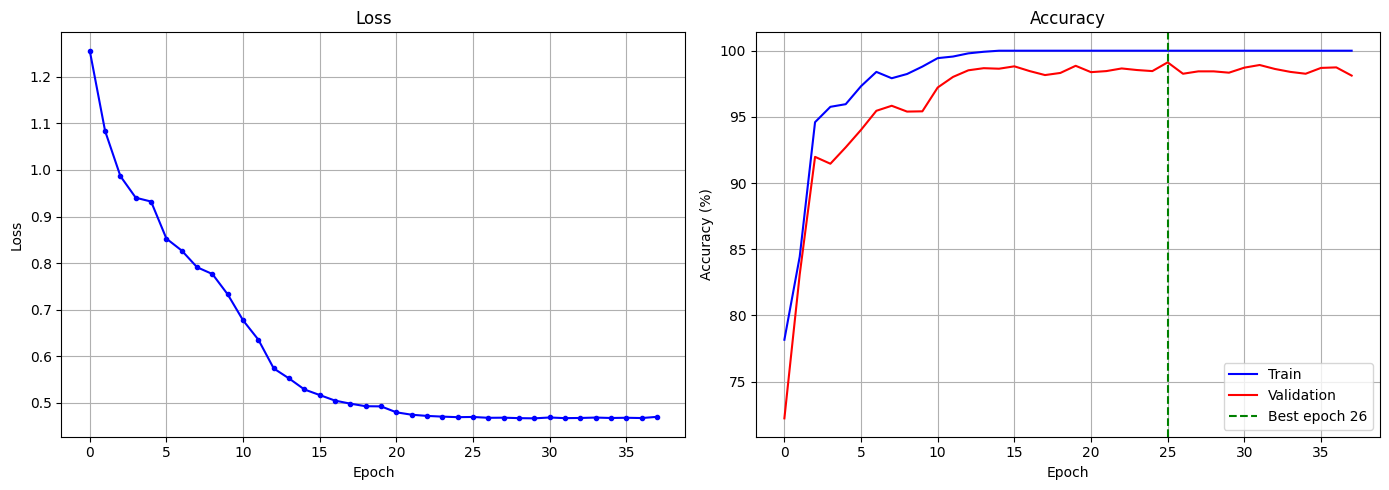

In [10]:
# =====================================================
# BOUCLE D'ENTRAÎNEMENT
# =====================================================
train_losses, train_accs, val_accs = [], [], []
best_val_acc, best_epoch            = 0.0, 0
patience_counter, EARLY_STOP        = 0, 12

print("\n🚀 Début entraînement\n")

for epoch in range(epochs):
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()

    # Curriculum : n_way croissant de 3 → 5 sur 20 epochs
    current_n_way = min(n_way, max(3, 3 + int((n_way - 3) * epoch / 20)))

    # Entraînement
    run_episodes(
        model, X_train, y_train,
        current_n_way, n_support, n_query,
        n_episodes_train, device,
        train=True, optimizer=optimizer, scaler=scaler,
        criterion=criterion, use_mixup=True
    )

    # Évaluation train
    train_loss, train_acc = run_episodes(
        model, X_train, y_train,
        n_way, n_support, n_query,
        50, device, criterion=criterion
    )

    # Évaluation validation
    _, val_acc = run_episodes(
        model, X_val, y_val,
        n_way, n_support, n_query,
        n_episodes_eval, device, criterion=criterion
    )

    scheduler.step()
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc     = val_acc
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pth"))
    else:
        patience_counter += 1

    temp = model.log_temperature.exp().item()
    gap  = (train_acc - val_acc) * 100
    flag = "⚠️ overfit" if gap > 10 else ("⚠️ leakage?" if val_acc > train_acc + 0.02 else "")

    print(f"{'⭐' if is_best else '  '} Epoch {epoch+1:3d}/{epochs} | "
          f"n_way={current_n_way} | Loss: {train_loss:.4f} | "
          f"Train: {train_acc*100:5.2f}% | Val: {val_acc*100:5.2f}% | "
          f"Gap: {gap:+.1f}% | T°: {temp:.2f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f} {flag}")

    if patience_counter >= EARLY_STOP:
        print(f"\n⏹️ Early stopping — epoch {epoch+1}")
        break

print(f"\n✅ Meilleure Val Acc : {best_val_acc*100:.2f}% (epoch {best_epoch+1})")

# --- Courbes ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot([a*100 for a in train_accs], 'b-', label='Train')
plt.plot([a*100 for a in val_accs],   'r-', label='Validation')
plt.axvline(best_epoch, color='g', linestyle='--', label=f'Best epoch {best_epoch+1}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Accuracy')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

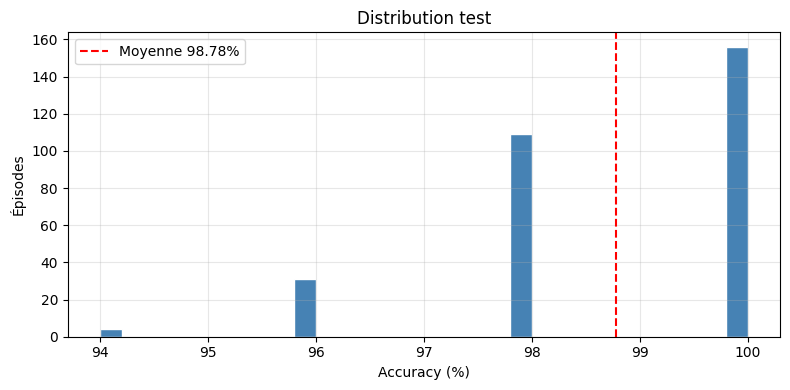


🧪 Test (300 épisodes) : 98.78% ± 0.16% (IC95%)
   Min: 94.0% | Max: 100.0% | Q10: 96.0%
   Température finale : 2.744

📁 Tout sauvegardé dans : /content/drive/MyDrive/lihar_results
   - best_model.pth
   - training_curves.png
   - test_distribution.png
   - results.json


In [11]:

# =====================================================
# ÉVALUATION FINALE — TEST SET
# =====================================================
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "best_model.pth"),
                                  map_location=device))
model.eval()

N_TEST = 300
all_accs = []
possible_classes = torch.unique(y_test).tolist()

with torch.no_grad():
    for _ in range(N_TEST):
        sup, qry, lbl = sample_episode(
            X_test, y_test, n_way, n_support, n_query, possible_classes
        )
        sup, qry, lbl = sup.to(device), qry.to(device), lbl.to(device)
        model.set_n_support(n_support)
        logits = model(sup, qry)
        all_accs.append((logits.argmax(1) == lbl).float().mean().item())
        del sup, qry, lbl, logits

all_accs = np.array(all_accs)
mean_acc = all_accs.mean()
ci95     = 1.96 * all_accs.std() / np.sqrt(N_TEST)

# Distribution des accuracies
plt.figure(figsize=(8, 4))
plt.hist(all_accs * 100, bins=30, color='steelblue', edgecolor='white')
plt.axvline(mean_acc * 100, color='red', linestyle='--',
            label=f'Moyenne {mean_acc*100:.2f}%')
plt.xlabel('Accuracy (%)'); plt.ylabel('Épisodes')
plt.title('Distribution test'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'test_distribution.png'), dpi=150)
plt.show()

print(f"\n🧪 Test ({N_TEST} épisodes) : {mean_acc*100:.2f}% ± {ci95*100:.2f}% (IC95%)")
print(f"   Min: {all_accs.min()*100:.1f}% | Max: {all_accs.max()*100:.1f}% | "
      f"Q10: {np.percentile(all_accs,10)*100:.1f}%")
print(f"   Température finale : {model.log_temperature.exp().item():.3f}")

# --- Sauvegarde résultats ---
results = {
    'best_val_acc':      float(best_val_acc),
    'test_mean_acc':     float(mean_acc),
    'test_ci95':         float(ci95),
    'test_min':          float(all_accs.min()),
    'test_q10':          float(np.percentile(all_accs, 10)),
    'epochs_done':       len(train_losses),
    'best_epoch':        best_epoch + 1,
    'n_way':             n_way,
    'n_support':         n_support,
    'n_query':           n_query,
    'final_temperature': float(model.log_temperature.exp().item())
}
with open(os.path.join(SAVE_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"\n📁 Tout sauvegardé dans : {SAVE_DIR}")
print("   - best_model.pth")
print("   - training_curves.png")
print("   - test_distribution.png")
print("   - results.json")